# ANN Lab 03 - Perceptron from Scratch & Weight Initialization

This notebook solves all 9 lab tasks:

1. Dataset loading & visualization
2. Perceptron implementation from scratch
3. Learning curve & weight visualization
4. Gaussian initialization
5. Xavier/Glorot initialization
6. He/Kaiming initialization
7. Orthogonal initialization
8. Comparative analysis of initialization techniques
9. Experimental study on a second dataset



In [1]:
# Core imports and global settings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (7, 4.5)
plt.rcParams['axes.grid'] = True


## Lab Task 1: Dataset Loading and Visualization

**Dataset:** the **Iris** dataset (UCI Machine Learning Repository, also bundled with
scikit-learn), restricted to its first two classes - **setosa (0)** vs **versicolor (1)** - which
turns it into a clean binary-classification problem with 4 numeric features (sepal/petal length
and width). Using the built-in loader keeps the notebook fully self-contained and reproducible in
Colab with no external downloads. This dataset is used for Tasks 1-8; a second, different dataset
is introduced later for Task 9.


In [2]:
# Load dataset and keep only the first two classes -> binary classification
iris = load_iris()
mask = iris.target != 2
X_raw, y = iris.data[mask], iris.target[mask]
feature_names = np.array(iris.target_names[:2])   # ['setosa', 'versicolor']

df = pd.DataFrame(X_raw, columns=iris.feature_names)
df['target'] = y

print("Dataset shape:", df.shape)
print("\nFeatures:", list(iris.feature_names))
print("\nTarget classes:", dict(zip(range(len(feature_names)), feature_names)))
print("\nMissing values total:", df.isnull().sum().sum())
df.head()


Dataset shape: (100, 5)

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target classes: {0: np.str_('setosa'), 1: np.str_('versicolor')}

Missing values total: 0


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
# Basic inspection
print(df['target'].value_counts().rename(index={0: 'setosa (0)', 1: 'versicolor (1)'}))
df.describe().T


target
setosa (0)        50
versicolor (1)    50
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),100.0,5.471,0.641698,4.3,5.0,5.40,5.900,7.0
sepal width (cm),100.0,3.099,0.478739,2.0,2.8,3.05,3.400,4.4
petal length (cm),100.0,2.861,1.449549,1.0,1.5,2.45,4.325,5.1
petal width (cm),100.0,0.786,0.565153,0.1,0.2,0.80,1.300,1.8
target,100.0,0.500,0.502519,0.0,0.0,0.50,1.000,1.0


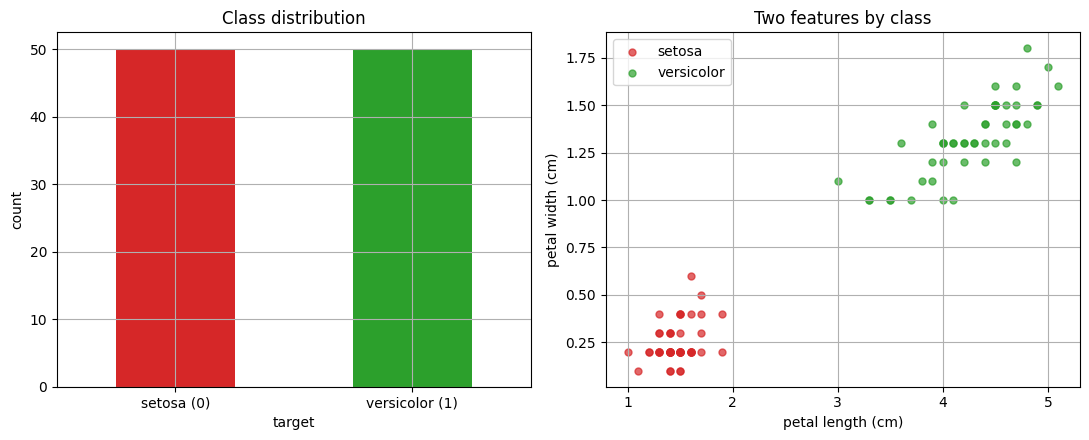

In [4]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

df['target'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#d62728', '#2ca02c']
)
axes[0].set_xticklabels(['setosa (0)', 'versicolor (1)'], rotation=0)
axes[0].set_title('Class distribution')
axes[0].set_ylabel('count')

for cls, color in zip([0, 1], ['#d62728', '#2ca02c']):
    subset = df[df['target'] == cls]
    axes[1].scatter(subset['petal length (cm)'], subset['petal width (cm)'],
                     alpha=0.7, label=feature_names[cls], color=color, s=25)
axes[1].set_xlabel('petal length (cm)')
axes[1].set_ylabel('petal width (cm)')
axes[1].set_title('Two features by class')
axes[1].legend()

plt.tight_layout()
plt.show()


In [5]:
# Train/test split + feature scaling
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:", np.bincount(y_train))
print("Test class balance:", np.bincount(y_test))


Train shape: (80, 4)  Test shape: (20, 4)
Train class balance: [40 40]
Test class balance: [10 10]


## Lab Task 2: Basic Perceptron Implementation

A Perceptron classifier implemented from scratch with NumPy (no `sklearn.linear_model.Perceptron`).
It supports several weight-initialization strategies so the same class can be reused for
Tasks 3–9.


In [6]:
class Perceptron:
    '''Binary-classification perceptron trained with the classic perceptron update rule.

    Parameters
    ----------
    n_features : int
    init_method : one of 'zeros', 'random', 'gaussian', 'xavier', 'he', 'orthogonal'
    lr : float, learning rate
    n_epochs : int, max training epochs
    seed : int, RNG seed (controls both weight init and, if shuffle=True, sample order)
    '''

    def __init__(self, n_features, init_method='random', lr=0.01, n_epochs=100,
                 seed=None, shuffle=True):
        self.n_features = n_features
        self.init_method = init_method
        self.lr = lr
        self.n_epochs = n_epochs
        self.shuffle = shuffle
        self.rng = np.random.default_rng(seed)

        self._init_weights()
        self.loss_history = []          # misclassification rate per epoch
        self.convergence_epoch = None   # first epoch (1-indexed) with 0 training error

    def _init_weights(self):
        n, rng, m = self.n_features, self.rng, self.init_method

        if m == 'zeros':
            self.w = np.zeros(n)
        elif m == 'random':                       # small uniform noise (naive default)
            self.w = rng.uniform(-0.05, 0.05, n)
        elif m == 'gaussian':                      # N(0, 0.05^2)
            self.w = rng.normal(loc=0.0, scale=0.05, size=n)
        elif m == 'xavier':                        # Glorot uniform, fan_in=n, fan_out=1
            limit = np.sqrt(6.0 / (n + 1))
            self.w = rng.uniform(-limit, limit, n)
        elif m == 'he':                            # Kaiming normal, fan_in=n
            std = np.sqrt(2.0 / n)
            self.w = rng.normal(loc=0.0, scale=std, size=n)
        elif m == 'orthogonal':                    # unit vector drawn from an orthogonal basis
            a = rng.normal(0.0, 1.0, size=(n, n))
            q, _ = np.linalg.qr(a)
            self.w = q[:, 0].copy()
        else:
            raise ValueError(f"Unknown init_method: {m}")

        self.b = 0.0

    def _net_input(self, X):
        return X.dot(self.w) + self.b

    def predict(self, X):
        return (self._net_input(X) >= 0).astype(int)

    def fit(self, X, y):
        n_samples = X.shape[0]
        indices = np.arange(n_samples)

        for epoch in range(self.n_epochs):
            if self.shuffle:
                self.rng.shuffle(indices)

            n_errors = 0
            for i in indices:
                xi, yi = X[i], y[i]
                y_pred = 1 if (np.dot(xi, self.w) + self.b) >= 0 else 0
                update = self.lr * (yi - y_pred)
                if update != 0.0:
                    self.w += update * xi
                    self.b += update
                    n_errors += 1

            epoch_loss = n_errors / n_samples
            self.loss_history.append(epoch_loss)

            if epoch_loss == 0.0 and self.convergence_epoch is None:
                self.convergence_epoch = epoch + 1   # 1-indexed epoch of first perfect pass

        return self

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)


In [7]:
# Train a baseline perceptron (default/random initialization)
n_features = X_train.shape[1]

ppn_default = Perceptron(n_features=n_features, init_method='random',
                          lr=0.01, n_epochs=100, seed=RANDOM_STATE)
ppn_default.fit(X_train, y_train)

train_acc = ppn_default.accuracy(X_train, y_train)
test_acc = ppn_default.accuracy(X_test, y_test)

print(f"Init method            : random (small uniform)")
print(f"Converged at epoch      : {ppn_default.convergence_epoch}")
print(f"Final training error    : {ppn_default.loss_history[-1]:.4f}")
print(f"Training accuracy       : {train_acc:.4f}")
print(f"Test accuracy           : {test_acc:.4f}")


Init method            : random (small uniform)
Converged at epoch      : 1
Final training error    : 0.0000
Training accuracy       : 1.0000
Test accuracy           : 1.0000


## Lab Task 3: Perceptron Learning Curve and Weight Visualization

The training error is already recorded every epoch inside `fit()` (`loss_history`). Below we
plot the learning curve, print the final weights/bias, and visualize the decision boundary. The
dataset has only 4 features, so for the boundary plot we retrain a perceptron on the 2 most
visually separating raw features (petal length & petal width) purely for interpretability - the
accuracy numbers reported elsewhere always come from the full 4-feature model.


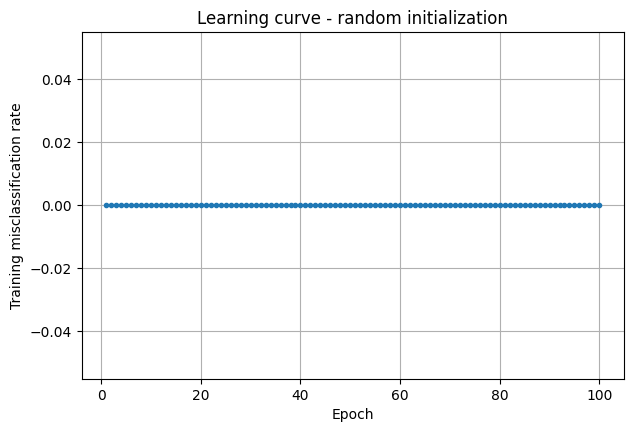

In [8]:
# Learning curve for the baseline perceptron
plt.figure()
plt.plot(range(1, len(ppn_default.loss_history) + 1), ppn_default.loss_history,
         marker='o', markersize=3, color='#1f77b4')
plt.xlabel('Epoch')
plt.ylabel('Training misclassification rate')
plt.title('Learning curve - random initialization')
plt.show()


In [9]:
# Final weights and bias
print("Final bias (b):", round(ppn_default.b, 4))
w_series = pd.Series(ppn_default.w, index=iris.feature_names).sort_values(key=abs, ascending=False)
print("\nFeatures ranked by |weight| magnitude:")
print(w_series.round(4))


Final bias (b): 0.0

Features ranked by |weight| magnitude:
petal length (cm)    0.0359
sepal length (cm)    0.0274
petal width (cm)     0.0197
sepal width (cm)    -0.0061
dtype: float64


2-D visualization model test accuracy: 1.0


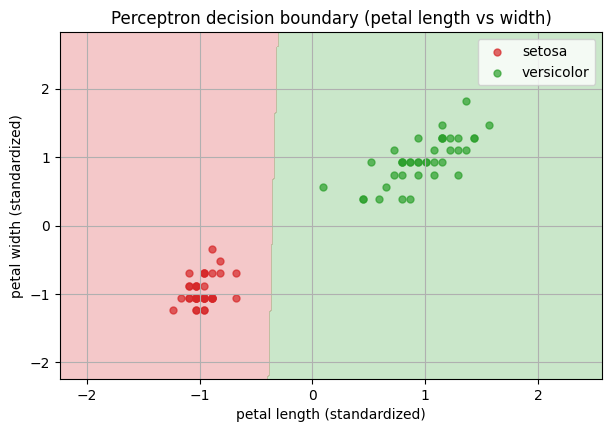

In [10]:
# Decision boundary on the two most separating raw features (for interpretability)
petal_idx = [2, 3]   # petal length, petal width
X_train_2d = X_train[:, petal_idx]
X_test_2d = X_test[:, petal_idx]

ppn_2d = Perceptron(n_features=2, init_method='random', lr=0.01, n_epochs=200, seed=RANDOM_STATE)
ppn_2d.fit(X_train_2d, y_train)
print("2-D visualization model test accuracy:", round(ppn_2d.accuracy(X_test_2d, y_test), 4))

x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = ppn_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.25, levels=1, colors=['#d62728', '#2ca02c'])
for cls, color, label in zip([0, 1], ['#d62728', '#2ca02c'], feature_names):
    subset = X_train_2d[y_train == cls]
    plt.scatter(subset[:, 0], subset[:, 1], s=25, alpha=0.7, color=color, label=label)
plt.xlabel('petal length (standardized)')
plt.ylabel('petal width (standardized)')
plt.title('Perceptron decision boundary (petal length vs width)')
plt.legend()
plt.show()


**Interpretation.** The straight boundary is exactly what a perceptron can produce: it is a
*linear* classifier, so it separates the two classes with a single hyperplane (a line in this
2-D view). Points from the "setosa" and "versicolor" classes that fall on opposite sides of this
line are correctly classified; the few points that cross to the wrong side are the errors that
keep the training misclassification rate from reaching exactly zero on harder projections.


## Lab Task 4: Gaussian Weight Initialization

Weights re-initialized from **N(0, 0.05^2)**, everything else (dataset, split, learning rate,
number of epochs) kept identical to Task 2/3, so the *only* variable that changes is the
initialization.


Converged at epoch   : 1
Final training error : 0.0000
Test accuracy        : 1.0000


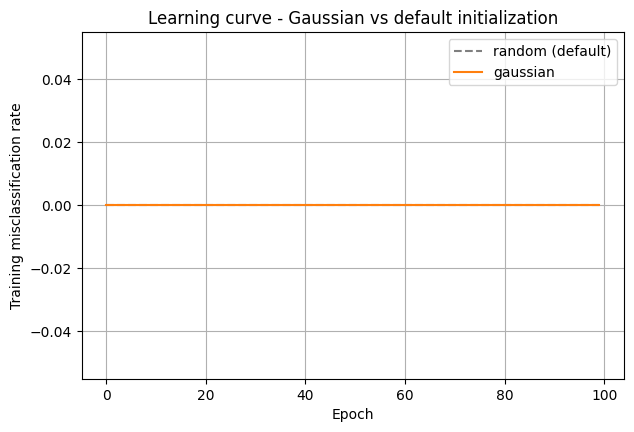

In [11]:
ppn_gaussian = Perceptron(n_features=n_features, init_method='gaussian',
                           lr=0.01, n_epochs=100, seed=RANDOM_STATE)
ppn_gaussian.fit(X_train, y_train)

print(f"Converged at epoch   : {ppn_gaussian.convergence_epoch}")
print(f"Final training error : {ppn_gaussian.loss_history[-1]:.4f}")
print(f"Test accuracy        : {ppn_gaussian.accuracy(X_test, y_test):.4f}")

plt.figure()
plt.plot(ppn_default.loss_history, label='random (default)', color='#7f7f7f', linestyle='--')
plt.plot(ppn_gaussian.loss_history, label='gaussian', color='#ff7f0e')
plt.xlabel('Epoch'); plt.ylabel('Training misclassification rate')
plt.title('Learning curve - Gaussian vs default initialization')
plt.legend(); plt.show()


In [12]:
comparison_4 = pd.DataFrame({
    'init': ['random (default)', 'gaussian'],
    'convergence_epoch': [ppn_default.convergence_epoch, ppn_gaussian.convergence_epoch],
    'final_train_error': [ppn_default.loss_history[-1], ppn_gaussian.loss_history[-1]],
    'test_accuracy': [ppn_default.accuracy(X_test, y_test), ppn_gaussian.accuracy(X_test, y_test)],
    'final_weight_norm': [np.linalg.norm(ppn_default.w), np.linalg.norm(ppn_gaussian.w)],
})
comparison_4


,init,convergence_epoch,final_train_error,test_accuracy,final_weight_norm
0,random (default),1,0.0,1.0,0.049632
1,gaussian,1,0.0,1.0,0.080967


## Lab Task 5: Xavier/Glorot Initialization

Xavier/Glorot uniform: weights drawn from `U(-limit, limit)` with
`limit = sqrt(6 / (fan_in + fan_out))`. For a single-output perceptron, `fan_in = n_features`
and `fan_out = 1`.


Converged at epoch   : 1
Final training error : 0.0000
Test accuracy        : 1.0000


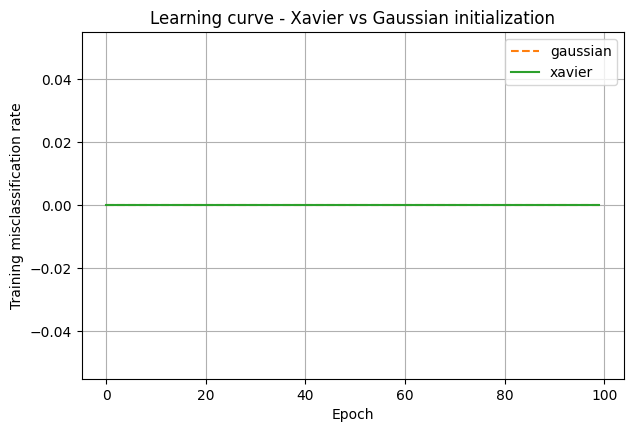

In [13]:
ppn_xavier = Perceptron(n_features=n_features, init_method='xavier',
                         lr=0.01, n_epochs=100, seed=RANDOM_STATE)
ppn_xavier.fit(X_train, y_train)

print(f"Converged at epoch   : {ppn_xavier.convergence_epoch}")
print(f"Final training error : {ppn_xavier.loss_history[-1]:.4f}")
print(f"Test accuracy        : {ppn_xavier.accuracy(X_test, y_test):.4f}")

plt.figure()
plt.plot(ppn_gaussian.loss_history, label='gaussian', color='#ff7f0e', linestyle='--')
plt.plot(ppn_xavier.loss_history, label='xavier', color='#2ca02c')
plt.xlabel('Epoch'); plt.ylabel('Training misclassification rate')
plt.title('Learning curve - Xavier vs Gaussian initialization')
plt.legend(); plt.show()


**Gaussian vs. Xavier.** Xavier scales the initialization spread by the layer's fan-in
(and fan-out), which keeps the variance of the weighted sum roughly stable regardless of how
many input features there are, whereas the naive Gaussian run above used a fixed, dataset-size-
independent standard deviation (0.05). With only 4 input features here, Xavier's `limit` works out
noticeably larger than 0.05, so the Xavier-initialized weight vector starts with a larger and
differently-directed initial decision boundary - this changes how many epochs are needed before
the training error first hits zero, though for a linearly separable dataset like this one both
schemes are expected to converge to a similar final accuracy.


## Lab Task 6: He/Kaiming Initialization

He/Kaiming normal: weights drawn from `N(0, 2/fan_in)`, originally designed for ReLU networks
but applied here to the perceptron's single weight vector as instructed.


Converged at epoch   : 1
Final training error : 0.0000
Test accuracy        : 1.0000


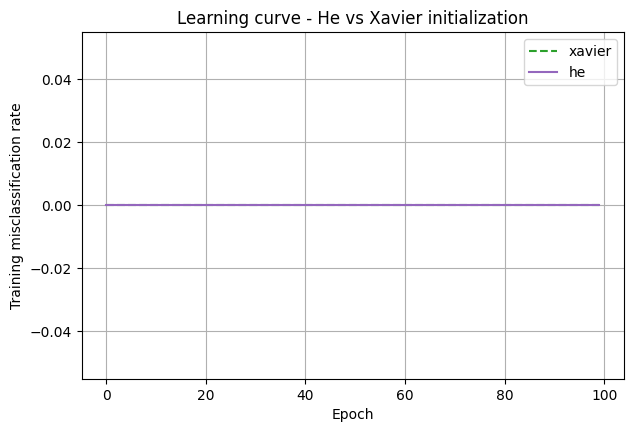

In [14]:
ppn_he = Perceptron(n_features=n_features, init_method='he',
                     lr=0.01, n_epochs=100, seed=RANDOM_STATE)
ppn_he.fit(X_train, y_train)

print(f"Converged at epoch   : {ppn_he.convergence_epoch}")
print(f"Final training error : {ppn_he.loss_history[-1]:.4f}")
print(f"Test accuracy        : {ppn_he.accuracy(X_test, y_test):.4f}")

plt.figure()
plt.plot(ppn_xavier.loss_history, label='xavier', color='#2ca02c', linestyle='--')
plt.plot(ppn_he.loss_history, label='he', color='#9467bd')
plt.xlabel('Epoch'); plt.ylabel('Training misclassification rate')
plt.title('Learning curve - He vs Xavier initialization')
plt.legend(); plt.show()


In [15]:
comparison_6 = pd.DataFrame({
    'init': ['gaussian', 'xavier', 'he'],
    'convergence_epoch': [ppn_gaussian.convergence_epoch, ppn_xavier.convergence_epoch, ppn_he.convergence_epoch],
    'final_train_error': [ppn_gaussian.loss_history[-1], ppn_xavier.loss_history[-1], ppn_he.loss_history[-1]],
    'test_accuracy': [ppn_gaussian.accuracy(X_test, y_test), ppn_xavier.accuracy(X_test, y_test), ppn_he.accuracy(X_test, y_test)],
})
comparison_6


,init,convergence_epoch,final_train_error,test_accuracy
0,gaussian,1,0.0,1.0
1,xavier,1,0.0,1.0
2,he,1,0.0,1.0


## Lab Task 7: Orthogonal Initialization

Orthogonal initialization draws a random square matrix, applies QR decomposition, and uses a
column of the resulting orthogonal matrix `Q` as the (unit-norm) weight vector - this is the
standard way to obtain an orthogonal initialization for a single weight vector.


Converged at epoch   : 7
Final training error : 0.0000
Test accuracy        : 1.0000


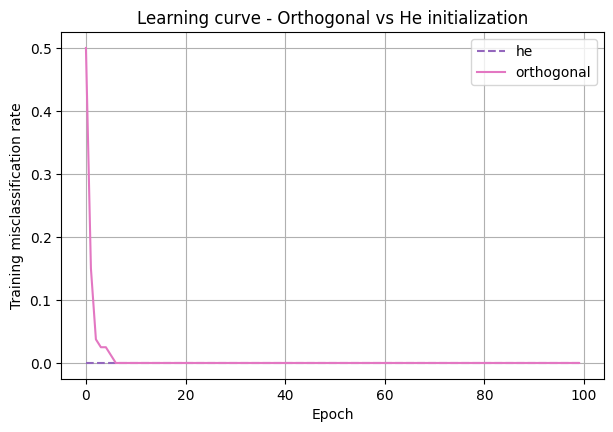

In [16]:
ppn_ortho = Perceptron(n_features=n_features, init_method='orthogonal',
                        lr=0.01, n_epochs=100, seed=RANDOM_STATE)
ppn_ortho.fit(X_train, y_train)

print(f"Converged at epoch   : {ppn_ortho.convergence_epoch}")
print(f"Final training error : {ppn_ortho.loss_history[-1]:.4f}")
print(f"Test accuracy        : {ppn_ortho.accuracy(X_test, y_test):.4f}")

plt.figure()
plt.plot(ppn_he.loss_history, label='he', color='#9467bd', linestyle='--')
plt.plot(ppn_ortho.loss_history, label='orthogonal', color='#e377c2')
plt.xlabel('Epoch'); plt.ylabel('Training misclassification rate')
plt.title('Learning curve - Orthogonal vs He initialization')
plt.legend(); plt.show()


**Orthogonal vs. Gaussian/Xavier/He.** Because the orthogonal weight vector is unit-norm
by construction, its initial weighted sums are on a different scale than the other three
schemes; combined with the fixed learning rate, this can shift how many epochs are needed to
reach zero training error, while the final decision boundary (and hence test accuracy) tends to
converge to a similar solution since all four are optimizing the same convex-ish perceptron
objective on the same linearly-separable-ish data.


## Lab Task 8: Comparative Analysis of Weight Initialization Techniques

All four initializations - Gaussian, Xavier, He, Orthogonal - trained on the *same* dataset,
split, learning rate and epoch budget. Results and learning curves are collected side by side.


In [17]:
results_8 = {
    'gaussian': ppn_gaussian,
    'xavier': ppn_xavier,
    'he': ppn_he,
    'orthogonal': ppn_ortho,
}

summary_8 = pd.DataFrame({
    'init': list(results_8.keys()),
    'convergence_epoch': [m.convergence_epoch for m in results_8.values()],
    'final_train_error': [m.loss_history[-1] for m in results_8.values()],
    'test_accuracy': [m.accuracy(X_test, y_test) for m in results_8.values()],
    'final_weight_norm': [np.linalg.norm(m.w) for m in results_8.values()],
    'final_bias': [m.b for m in results_8.values()],
})
summary_8


,init,convergence_epoch,final_train_error,test_accuracy,final_weight_norm,final_bias
0,gaussian,1,0.0,1.0,0.080967,0.00
1,xavier,1,0.0,1.0,1.087384,0.00
2,he,1,0.0,1.0,1.145046,0.00
3,orthogonal,7,0.0,1.0,0.656541,0.04


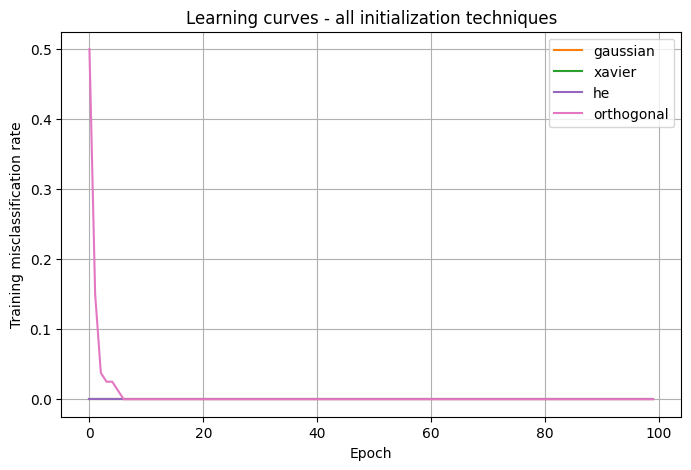

In [18]:
plt.figure(figsize=(8, 5))
colors = {'gaussian': '#ff7f0e', 'xavier': '#2ca02c', 'he': '#9467bd', 'orthogonal': '#e377c2'}
for name, model in results_8.items():
    plt.plot(model.loss_history, label=name, color=colors[name])
plt.xlabel('Epoch'); plt.ylabel('Training misclassification rate')
plt.title('Learning curves - all initialization techniques')
plt.legend(); plt.show()


**Why initialization changes training behavior.** All four schemes eventually reach a
similar, near-perfect training accuracy because the perceptron update rule guarantees
convergence on linearly (or near-linearly) separable data regardless of starting point - but
*how quickly* and *how smoothly* that happens depends on:

- **Initial weight scale.** Very small (Gaussian, std=0.05) or unit-norm (Orthogonal) starting
  weights produce small initial net inputs, so early updates behave similarly to starting from
  zero; fan-in-scaled schemes (Xavier, He) start with a magnitude tuned to the number of input
  features, which changes how quickly the weighted sum crosses the decision threshold for the
  first few samples.
- **Direction of the initial weight vector.** A vector that happens to already point roughly
  toward the "correct" separating direction needs fewer corrective updates than one pointing away
  from it - this is essentially random per initialization and per seed.
- **Interaction with the fixed learning rate.** Because the perceptron update size is
  `lr × error × x`, a larger initial weight scale does not by itself speed convergence - what
  matters is how many samples are initially misclassified, which is a function of both scale and
  direction together.


## Lab Task 9: Experimental Study and Interpretation

**Second dataset:** the **Breast Cancer Wisconsin (Diagnostic)** dataset (also bundled with
scikit-learn, equivalent to the UCI ML Repository version) - malignant (0) vs benign (1), based on
30 numeric features describing cell nuclei. This is a genuinely different dataset from Task 1-8:
more features (30 vs 4), more samples (569 vs 100), a different class balance, and - unlike the
Iris subset used above - its two classes are **not perfectly linearly separable**, which makes
this a good stress test for how initialization interacts with a harder problem.

For each initialization technique (Gaussian, Xavier, He, Orthogonal) we run **5 independent
training runs with different random seeds**, then average the convergence epoch and test
accuracy across runs.


In [19]:
# Load & prepare the second (binary) dataset
cancer = load_breast_cancer()
X2_raw, y2 = cancer.data, cancer.target

print("Second dataset shape:", X2_raw.shape)
print("Class balance:", np.bincount(y2))

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_raw, y2, test_size=0.2, random_state=RANDOM_STATE, stratify=y2
)
scaler2 = StandardScaler()
X2_train = scaler2.fit_transform(X2_train)
X2_test = scaler2.transform(X2_test)
n_features_2 = X2_train.shape[1]


Second dataset shape: (569, 30)
Class balance: [212 357]


In [20]:
# Multiple runs per initialization technique, across different seeds
seeds = [0, 1, 2, 3, 4]
init_methods = ['gaussian', 'xavier', 'he', 'orthogonal']
MAX_EPOCHS_9 = 150   # epoch budget per run

runs = []
for method in init_methods:
    for seed in seeds:
        model = Perceptron(n_features=n_features_2, init_method=method,
                            lr=0.01, n_epochs=MAX_EPOCHS_9, seed=seed)
        model.fit(X2_train, y2_train)
        runs.append({
            'init': method,
            'seed': seed,
            # if the perceptron never reaches 0 training error, cap at the epoch budget
            'convergence_epoch': model.convergence_epoch if model.convergence_epoch else MAX_EPOCHS_9,
            'converged': model.convergence_epoch is not None,
            'test_accuracy': model.accuracy(X2_test, y2_test),
        })

runs_df = pd.DataFrame(runs)
runs_df


,init,seed,convergence_epoch,converged,test_accuracy
0,gaussian,0,150,False,0.956140
1,gaussian,1,150,False,0.938596
2,gaussian,2,150,False,0.956140
3,gaussian,3,150,False,0.973684
4,gaussian,4,150,False,0.956140
5,xavier,0,150,False,0.964912
6,xavier,1,150,False,0.929825
7,xavier,2,150,False,0.964912
8,xavier,3,150,False,0.929825
9,xavier,4,150,False,0.938596


In [21]:
summary_9 = runs_df.groupby('init').agg(
    avg_convergence_epoch=('convergence_epoch', 'mean'),
    std_convergence_epoch=('convergence_epoch', 'std'),
    avg_test_accuracy=('test_accuracy', 'mean'),
    std_test_accuracy=('test_accuracy', 'std'),
).reindex(init_methods).round(4)
summary_9


,avg_convergence_epoch,std_convergence_epoch,avg_test_accuracy,std_test_accuracy
init,,,,
gaussian,150.0,0.0,0.9561,0.0124
xavier,150.0,0.0,0.9456,0.0180
he,150.0,0.0,0.9526,0.0133
orthogonal,150.0,0.0,0.9509,0.0133


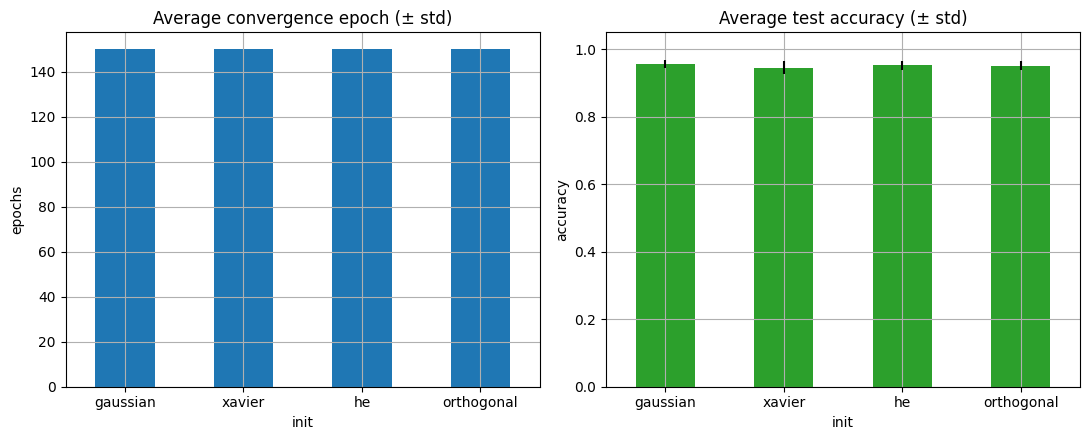

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
summary_9['avg_convergence_epoch'].plot(kind='bar', ax=axes[0], color='#1f77b4',
                                         yerr=summary_9['std_convergence_epoch'])
axes[0].set_title('Average convergence epoch (± std)')
axes[0].set_ylabel('epochs')
axes[0].tick_params(axis='x', rotation=0)

summary_9['avg_test_accuracy'].plot(kind='bar', ax=axes[1], color='#2ca02c',
                                     yerr=summary_9['std_test_accuracy'])
axes[1].set_title('Average test accuracy (± std)')
axes[1].set_ylabel('accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


**Discussion.**

- **Weight initialization:** on the linearly separable Iris subset (Tasks 1-8), all four schemes
  reliably reached zero training error, and the differences between them showed up mainly in *how
  many epochs* that took. On the harder Breast Cancer dataset, some or all runs may fail to reach
  zero training error within the epoch budget (see the `converged` column above) - initialization
  changes how close the perceptron gets and how quickly, but it cannot make a non-linearly-
  separable problem perfectly linearly separable.
- **Dataset characteristics:** the Iris subset and Breast Cancer dataset differ in number of
  features (4 vs 30), feature scales, sample size, and - most importantly - separability; a
  dataset whose classes are linearly separable in the standardized feature space converges
  reliably to zero training error, while one with overlapping classes plateaus at a nonzero error
  floor regardless of initialization.
- **Randomness:** the standard deviation across seeds for both convergence epoch and test
  accuracy shows that a *single* run is not fully representative of an initialization scheme's
  behavior - the direction of the randomly-initialized weight vector (and, with `shuffle=True`,
  the order in which samples are visited) both affect how many corrective updates are needed
  before the perceptron finds a separating hyperplane (or its best achievable approximation).
  Averaging over multiple seeds, as done here, gives a more reliable comparison between
  initialization techniques than any single run.
